In [46]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.inspection import PartialDependenceDisplay
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import clone

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [47]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "processed_data")
RESULTS_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "results")

In [49]:
# import IEA scored data
policy_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "IEA_scored_cpsi.csv"))
policy_df.head()

,iso_alpha_3,year,avg_score,policy_count,dominant_topic,dominant_category,CPSI
0,AFG,1971,0.75,1,Energy,Solar Power,0.51986
1,AFG,1972,0.75,1,Energy,Solar Power,0.51986
2,AFG,1973,0.75,1,Energy,Solar Power,0.51986
3,AFG,1974,0.75,1,Energy,Solar Power,0.51986
4,AFG,1975,0.75,1,Energy,Solar Power,0.51986


In [50]:
policy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9255 entries, 0 to 9254
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   iso_alpha_3        9255 non-null   object 
 1   year               9255 non-null   int64  
 2   avg_score          9255 non-null   float64
 3   policy_count       9255 non-null   int64  
 4   dominant_topic     9255 non-null   object 
 5   dominant_category  9255 non-null   object 
 6   CPSI               9255 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 506.3+ KB


In [51]:
# import emissions data
emissions_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "total_emissions_db.csv"))
emissions_df.head()

,iso_alpha_3,income_group,year,total_emissions
0,ABW,High income,2000,0.335765
1,ABW,High income,2001,0.344135
2,ABW,High income,2002,0.363222
3,ABW,High income,2003,0.412246
4,ABW,High income,2004,0.430187


In [52]:
emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4485 entries, 0 to 4484
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   iso_alpha_3      4485 non-null   object 
 1   income_group     4485 non-null   object 
 2   year             4485 non-null   int64  
 3   total_emissions  4485 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 140.3+ KB


In [53]:
# import wb controls
wb_controls_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "wb_control_vars.csv"))
wb_controls_df.head()

,year,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area,iso_alpha_3
0,2022,1.040350e+12,731821393.0,565.488909,NaN,7.303970,37.909012,26.921919,29.737205,NaN
1,2021,1.004646e+12,713090928.0,570.998888,NaN,7.156658,37.393633,26.075267,29.955194,NaN
2,2020,9.606813e+11,694446100.0,563.976201,66.123449,7.107927,36.884034,25.434235,30.174252,NaN
3,2019,9.890095e+11,675950189.0,586.441491,63.387090,7.212707,36.384272,26.421751,30.391626,NaN
4,2018,9.677734e+11,657801085.0,583.763039,62.242631,7.273489,35.893398,27.859732,30.611512,NaN


In [54]:
wb_controls_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6118 entries, 0 to 6117
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               6118 non-null   int64  
 1   gdp_2015_usd       5832 non-null   float64
 2   population         6095 non-null   float64
 3   energy_per_capita  4565 non-null   float64
 4   renewable_share    5710 non-null   float64
 5   energy_intensity   4404 non-null   float64
 6   urbanization_rate  6049 non-null   float64
 7   industry_size      5551 non-null   float64
 8   forest_area        5953 non-null   float64
 9   iso_alpha_3        4945 non-null   object 
dtypes: float64(8), int64(1), object(1)
memory usage: 478.1+ KB


In [55]:
policy_emissions_df = pd.merge(policy_df, emissions_df, on=["iso_alpha_3", "year"], how="inner")
policy_emissions_df.head()

,iso_alpha_3,year,avg_score,policy_count,dominant_topic,dominant_category,CPSI,income_group,total_emissions
0,AFG,2000,0.75,1,Energy,Solar Power,0.51986,Low income,25.390391
1,AFG,2001,0.75,1,Energy,Solar Power,0.51986,Low income,23.723115
2,AFG,2002,0.75,1,Energy,Solar Power,0.51986,Low income,26.383509
3,AFG,2003,0.75,1,Energy,Solar Power,0.51986,Low income,27.071538
4,AFG,2004,0.75,1,Energy,Solar Power,0.51986,Low income,27.128799


In [56]:
# check if USA is in the data
policy_emissions_df[policy_emissions_df["iso_alpha_3"] == "USA"].head()

,iso_alpha_3,year,avg_score,policy_count,dominant_topic,dominant_category,CPSI,income_group,total_emissions
3965,USA,2000,0.459459,74,Cross-cutting / Economy-wide,Other,1.983711,High income,6318.595153
3966,USA,2001,0.460366,82,Cross-cutting / Economy-wide,Other,2.034283,High income,6237.645614
3967,USA,2002,0.446809,94,Cross-cutting / Economy-wide,Other,2.034711,High income,6102.809992
3968,USA,2003,0.444175,103,Cross-cutting / Economy-wide,Other,2.062921,High income,6142.901629
3969,USA,2004,0.461864,118,Cross-cutting / Economy-wide,Other,2.207307,High income,6313.734481


In [57]:
wb_controls_df[wb_controls_df["iso_alpha_3"] == "USA"].head()

,year,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area,iso_alpha_3
5865,2022,2.144339e+13,333271411.0,6520.176697,NaN,11.171772,83.084,NaN,33.866926,USA
5866,2021,2.091785e+13,332048977.0,6441.742879,10.9,11.071275,82.873,17.608172,33.866926,USA
5867,2020,1.972358e+13,331526933.0,6138.375293,11.0,10.972348,82.664,17.267677,33.866926,USA
5868,2019,2.015964e+13,328329953.0,6736.457903,10.2,10.318741,82.459,18.145484,33.866926,USA
5869,2018,1.965187e+13,326838199.0,6770.788961,9.9,10.053513,82.256,18.519546,33.866926,USA


In [58]:
# Now let's merge the wb controls data
policy_emissions_df = pd.merge(policy_emissions_df, wb_controls_df, on=["iso_alpha_3", "year"], how="inner")
policy_emissions_df.head()

,iso_alpha_3,year,avg_score,policy_count,dominant_topic,dominant_category,CPSI,income_group,total_emissions,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area
0,AFG,2000,0.75,1,Energy,Solar Power,0.51986,Low income,25.390391,6.206548e+09,20130327.0,NaN,45.0,NaN,22.078,NaN,1.852782
1,AFG,2001,0.75,1,Energy,Solar Power,0.51986,Low income,23.723115,5.621148e+09,20284307.0,NaN,45.6,NaN,22.169,NaN,1.852782
2,AFG,2002,0.75,1,Energy,Solar Power,0.51986,Low income,26.383509,7.228796e+09,21378117.0,NaN,37.8,NaN,22.261,23.810127,1.852782
3,AFG,2003,0.75,1,Energy,Solar Power,0.51986,Low income,27.071538,7.867263e+09,22733049.0,NaN,36.7,NaN,22.353,22.710864,1.852782
4,AFG,2004,0.75,1,Energy,Solar Power,0.51986,Low income,27.128799,7.978516e+09,23560654.0,NaN,44.2,NaN,22.500,26.226790,1.852782


In [59]:
# check if USA is in the data
policy_emissions_df[policy_emissions_df["iso_alpha_3"] == "USA"].head()


,iso_alpha_3,year,avg_score,policy_count,dominant_topic,dominant_category,CPSI,income_group,total_emissions,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area
3943,USA,2000,0.459459,74,Cross-cutting / Economy-wide,Other,1.983711,High income,6318.595153,1.371768e+13,282162411.0,8055.145489,5.4,6.832729,79.057,22.451577,33.130174
3944,USA,2001,0.460366,82,Cross-cutting / Economy-wide,Other,2.034283,High income,6237.645614,1.384876e+13,284968955.0,7824.243939,4.7,7.031645,79.234,21.469006,33.186756
3945,USA,2002,0.446809,94,Cross-cutting / Economy-wide,Other,2.034711,High income,6102.809992,1.408425e+13,287625193.0,7840.460959,4.8,7.070518,79.409,20.652475,33.243338
3946,USA,2003,0.444175,103,Cross-cutting / Economy-wide,Other,2.062921,High income,6142.901629,1.447799e+13,290107933.0,7791.303915,5.3,7.251444,79.583,20.739462,33.299920
3947,USA,2004,0.461864,118,Cross-cutting / Economy-wide,Other,2.207307,High income,6313.734481,1.503507e+13,292805298.0,7878.537171,5.5,7.378481,79.757,20.950032,33.356502


In [60]:
## remove unnecessary columns
policy_emissions_df = policy_emissions_df.drop(columns=["avg_score", 
                                                        "policy_count", 
                                                        "dominant_topic",
                                                        "dominant_category",
                                                        "income_group"])

# move total_emissions to the end
policy_emissions_df = policy_emissions_df[[col for col in policy_emissions_df.columns if col != "total_emissions"] + ["total_emissions"]]
policy_emissions_df.head()

,iso_alpha_3,year,CPSI,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area,total_emissions
0,AFG,2000,0.51986,6.206548e+09,20130327.0,NaN,45.0,NaN,22.078,NaN,1.852782,25.390391
1,AFG,2001,0.51986,5.621148e+09,20284307.0,NaN,45.6,NaN,22.169,NaN,1.852782,23.723115
2,AFG,2002,0.51986,7.228796e+09,21378117.0,NaN,37.8,NaN,22.261,23.810127,1.852782,26.383509
3,AFG,2003,0.51986,7.867263e+09,22733049.0,NaN,36.7,NaN,22.353,22.710864,1.852782,27.071538
4,AFG,2004,0.51986,7.978516e+09,23560654.0,NaN,44.2,NaN,22.500,26.226790,1.852782,27.128799


In [61]:
# Create a rel_change column per country
policy_emissions_df["rel_change"] = policy_emissions_df.groupby("iso_alpha_3")["total_emissions"].pct_change()

# Drop NaNs in rel_change
policy_emissions_df = policy_emissions_df.dropna(subset=["rel_change"])

policy_emissions_df

,iso_alpha_3,year,CPSI,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area,total_emissions,rel_change
1,AFG,2001,0.519860,5.621148e+09,20284307.0,NaN,45.6,NaN,22.169,NaN,1.852782,23.723115,-0.065666
2,AFG,2002,0.519860,7.228796e+09,21378117.0,NaN,37.8,NaN,22.261,23.810127,1.852782,26.383509,0.112144
3,AFG,2003,0.519860,7.867263e+09,22733049.0,NaN,36.7,NaN,22.353,22.710864,1.852782,27.071538,0.026078
4,AFG,2004,0.519860,7.978516e+09,23560654.0,NaN,44.2,NaN,22.500,26.226790,1.852782,27.128799,0.002115
5,AFG,2005,0.519860,8.874480e+09,24404567.0,NaN,33.9,NaN,22.703,26.812099,1.852782,27.530896,0.014822
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4160,ZWE,2018,1.524829,2.201518e+10,15034452.0,445.175095,79.7,8.026019,32.209,31.037898,45.332093,47.509033,0.046201
4161,ZWE,2019,1.603093,2.062108e+10,15271368.0,412.165420,81.0,7.993893,32.210,32.025947,45.213002,46.442562,-0.022448
4162,ZWE,2020,1.603093,1.900914e+10,15526888.0,373.557246,84.1,7.996819,32.242,32.767517,45.093912,44.576343,-0.040183
4163,ZWE,2021,1.547457,2.061884e+10,15797210.0,405.518564,82.4,7.853612,32.303,28.805586,44.974822,45.759664,0.026546


In [62]:
policy_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3976 entries, 1 to 4164
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   iso_alpha_3        3976 non-null   object 
 1   year               3976 non-null   int64  
 2   CPSI               3976 non-null   float64
 3   gdp_2015_usd       3907 non-null   float64
 4   population         3976 non-null   float64
 5   energy_per_capita  3201 non-null   float64
 6   renewable_share    3840 non-null   float64
 7   energy_intensity   3109 non-null   float64
 8   urbanization_rate  3976 non-null   float64
 9   industry_size      3821 non-null   float64
 10  forest_area        3940 non-null   float64
 11  total_emissions    3976 non-null   float64
 12  rel_change         3976 non-null   float64
dtypes: float64(11), int64(1), object(1)
memory usage: 434.9+ KB


In [63]:
oecd_countries_iso3 = [
    "AUS",  # Australia
    "AUT",  # Austria
    "BEL",  # Belgium
    "CAN",  # Canada
    "CHL",  # Chile
    "COL",  # Colombia
    "CZE",  # Czech Republic
    "DNK",  # Denmark
    "EST",  # Estonia
    "FIN",  # Finland
    "FRA",  # France
    "DEU",  # Germany
    "GRC",  # Greece
    "HUN",  # Hungary
    "ISL",  # Iceland
    "IRL",  # Ireland
    "ISR",  # Israel
    "ITA",  # Italy
    "JPN",  # Japan
    "KOR",  # South Korea
    "LVA",  # Latvia
    "LTU",  # Lithuania
    "LUX",  # Luxembourg
    "MEX",  # Mexico
    "NLD",  # Netherlands
    "NZL",  # New Zealand
    "NOR",  # Norway
    "POL",  # Poland
    "PRT",  # Portugal
    "SVK",  # Slovakia
    "SVN",  # Slovenia
    "ESP",  # Spain
    "SWE",  # Sweden
    "CHE",  # Switzerland
    "TUR",  # Turkey
    "GBR",  # United Kingdom
    "USA"   # United States
]

In [64]:
oecd_policy_emissions_df = policy_emissions_df[policy_emissions_df["iso_alpha_3"].isin(oecd_countries_iso3)].reset_index(drop=True)
oecd_policy_emissions_df.head()

,iso_alpha_3,year,CPSI,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area,total_emissions,rel_change
0,AUS,2001,1.868549,8.903238e+11,19274701.0,5486.394559,8.4,8.263839,84.100,23.633521,17.128633,602.437642,0.036145
1,AUS,2002,1.892528,9.257550e+11,19495210.0,5480.234643,8.7,8.505064,84.222,23.611732,17.099111,606.209253,0.006261
2,AUS,2003,2.119532,9.543678e+11,19720737.0,5615.576756,7.2,8.458763,84.343,24.042096,17.069589,607.749769,0.002541
3,AUS,2004,2.201468,9.946831e+11,19932722.0,5652.130379,6.7,8.665917,84.463,23.934919,17.040066,608.183791,0.000714
4,AUS,2005,2.304892,1.026057e+12,20176844.0,5624.495613,6.7,8.874487,84.582,24.618507,17.010544,636.879313,0.047182


In [65]:
oecd_policy_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 810 entries, 0 to 809
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   iso_alpha_3        810 non-null    object 
 1   year               810 non-null    int64  
 2   CPSI               810 non-null    float64
 3   gdp_2015_usd       810 non-null    float64
 4   population         810 non-null    float64
 5   energy_per_capita  810 non-null    float64
 6   renewable_share    773 non-null    float64
 7   energy_intensity   810 non-null    float64
 8   urbanization_rate  810 non-null    float64
 9   industry_size      806 non-null    float64
 10  forest_area        809 non-null    float64
 11  total_emissions    810 non-null    float64
 12  rel_change         810 non-null    float64
dtypes: float64(11), int64(1), object(1)
memory usage: 82.4+ KB


In [66]:
oecd_policy_emissions_df[oecd_policy_emissions_df["iso_alpha_3"] == "USA"].head()

,iso_alpha_3,year,CPSI,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area,total_emissions,rel_change
788,USA,2001,2.034283,1.384876e+13,284968955.0,7824.243939,4.7,7.031645,79.234,21.469006,33.186756,6237.645614,-0.012811
789,USA,2002,2.034711,1.408425e+13,287625193.0,7840.460959,4.8,7.070518,79.409,20.652475,33.243338,6102.809992,-0.021616
790,USA,2003,2.062921,1.447799e+13,290107933.0,7791.303915,5.3,7.251444,79.583,20.739462,33.299920,6142.901629,0.006569
791,USA,2004,2.207307,1.503507e+13,292805298.0,7878.537171,5.5,7.378481,79.757,20.950032,33.356502,6313.734481,0.027810
792,USA,2005,2.283475,1.555882e+13,295516599.0,7843.391057,5.8,7.599360,79.928,21.206273,33.413084,6263.301581,-0.007988


## EDA

In [67]:
from utils.eda_utils import PolicyEDA

eda = PolicyEDA()

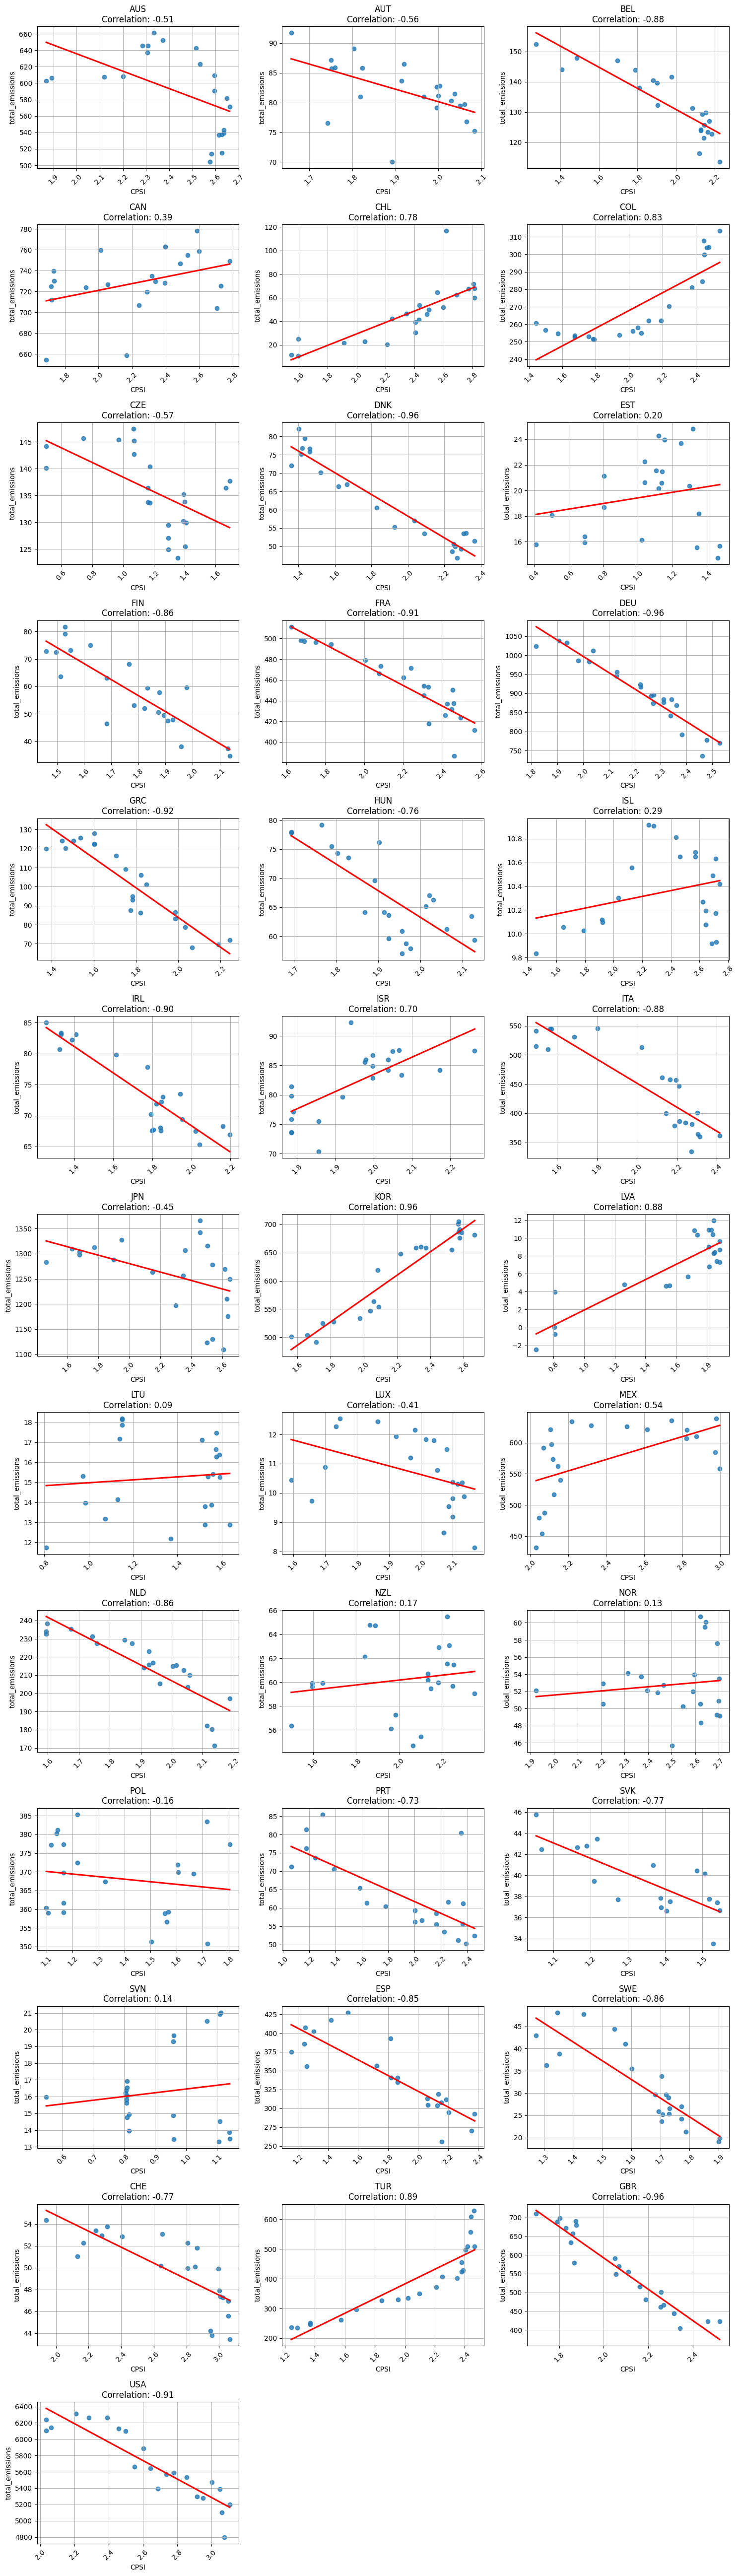

In [68]:
eda.plot_correlation_multiple(policy_emissions_df, "CPSI", "total_emissions", oecd_countries_iso3)

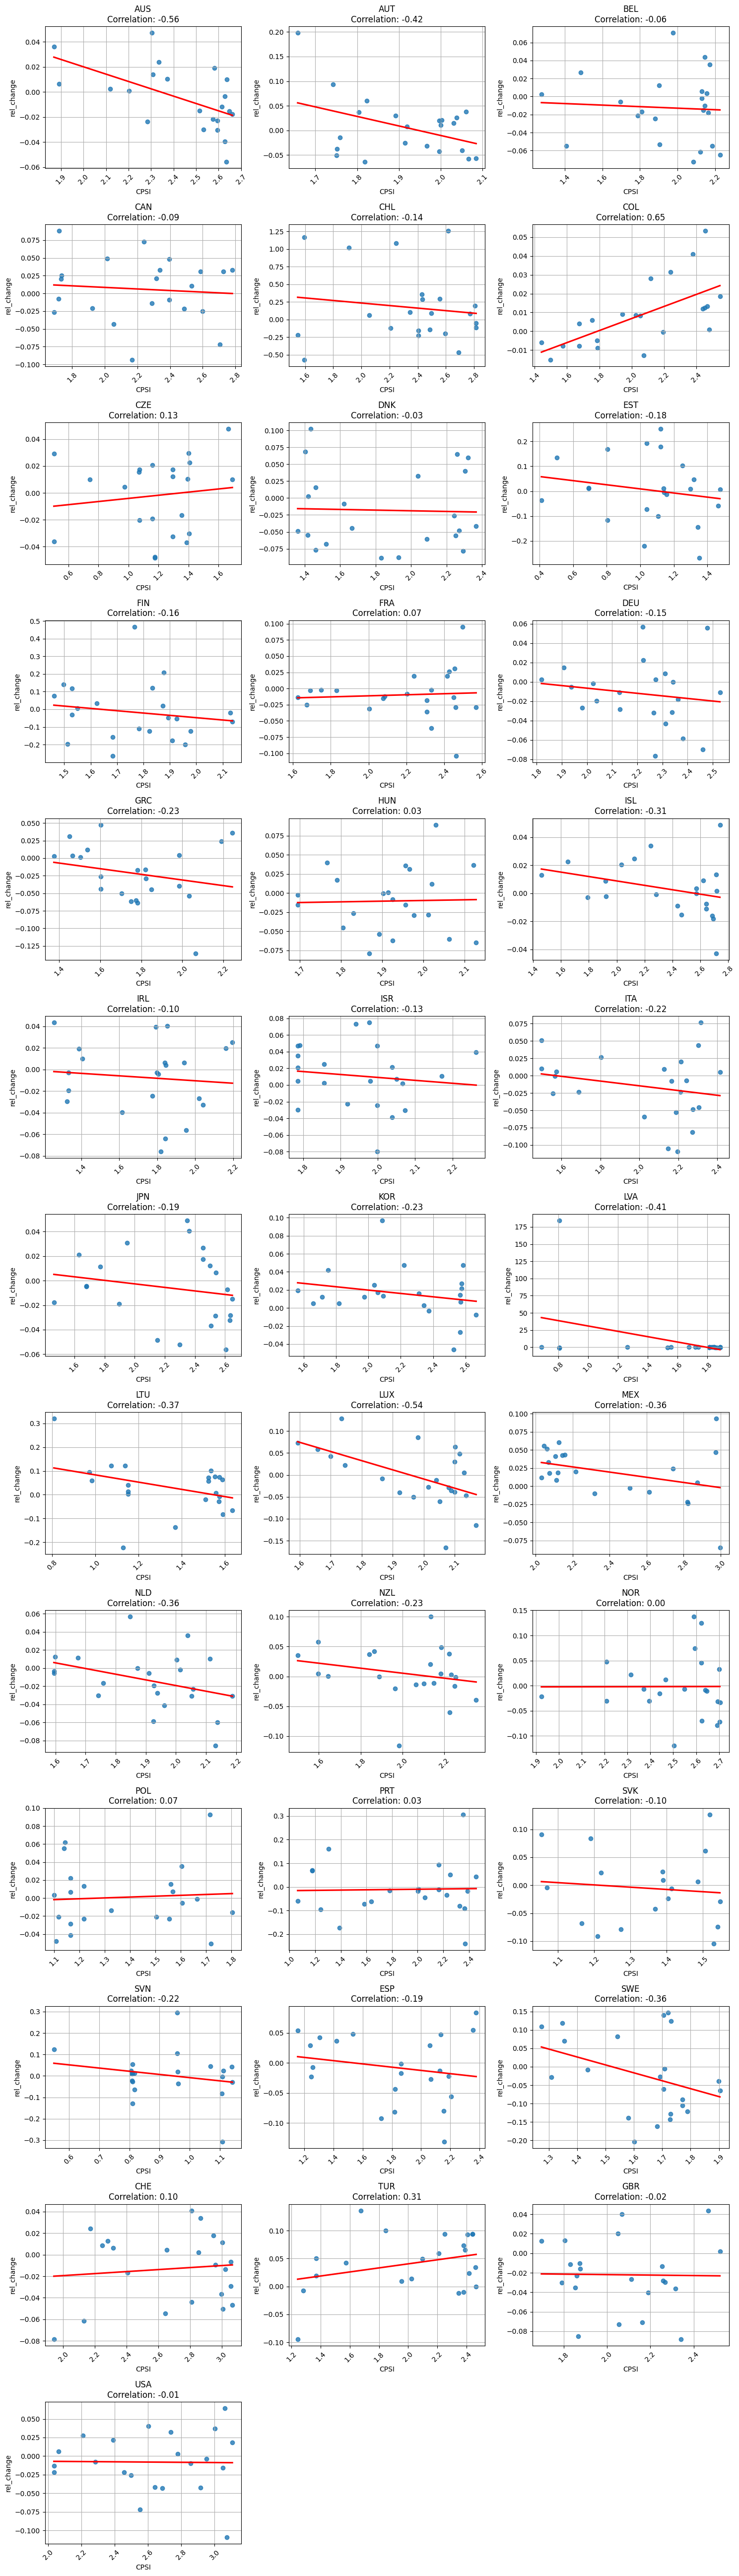

In [69]:
eda.plot_correlation_multiple(policy_emissions_df, "CPSI", "rel_change", oecd_countries_iso3)

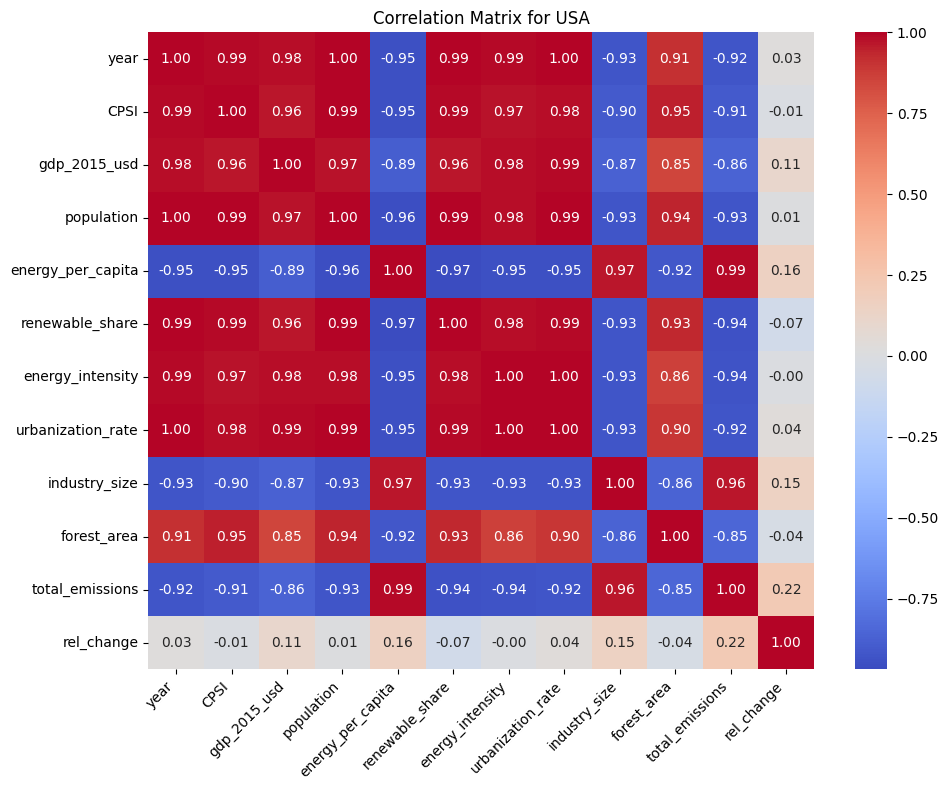

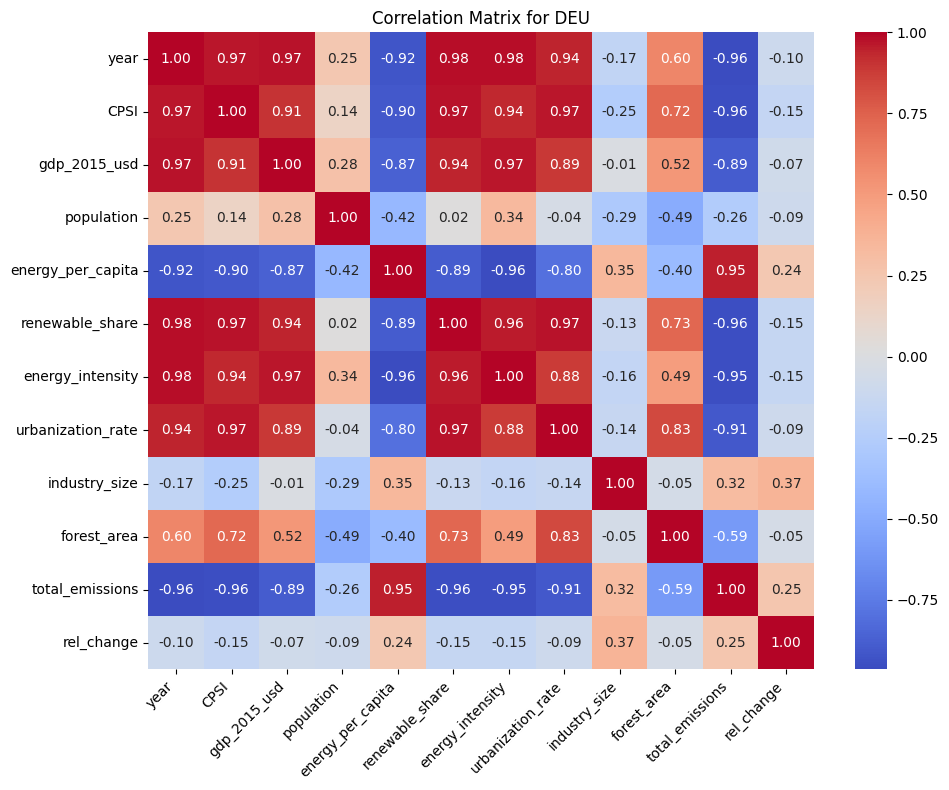

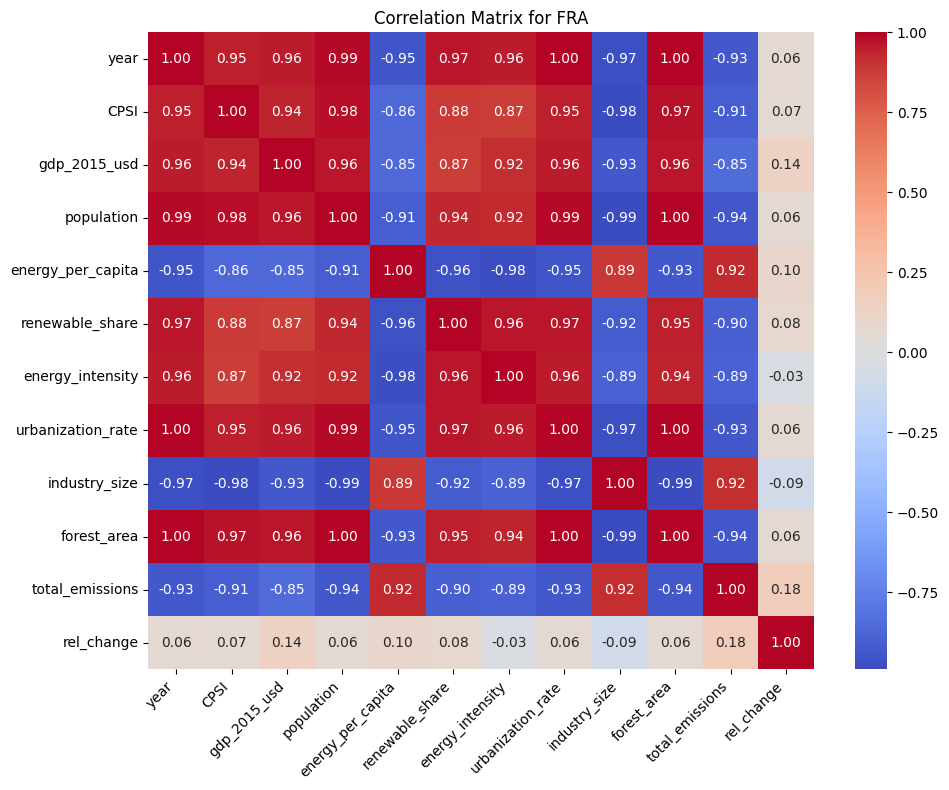

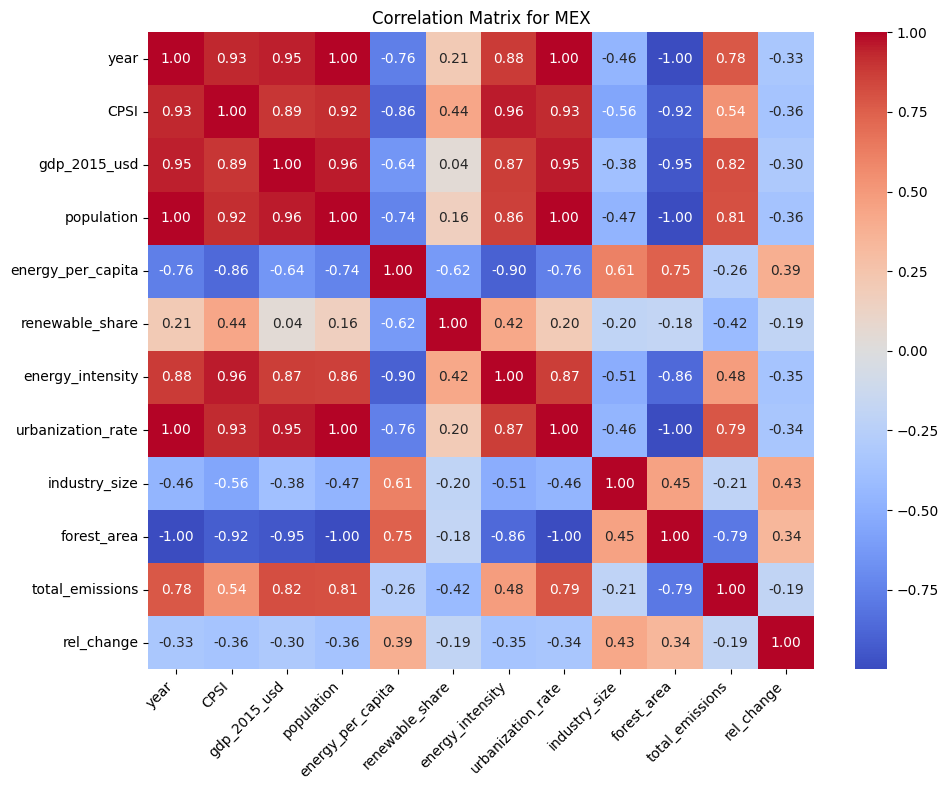

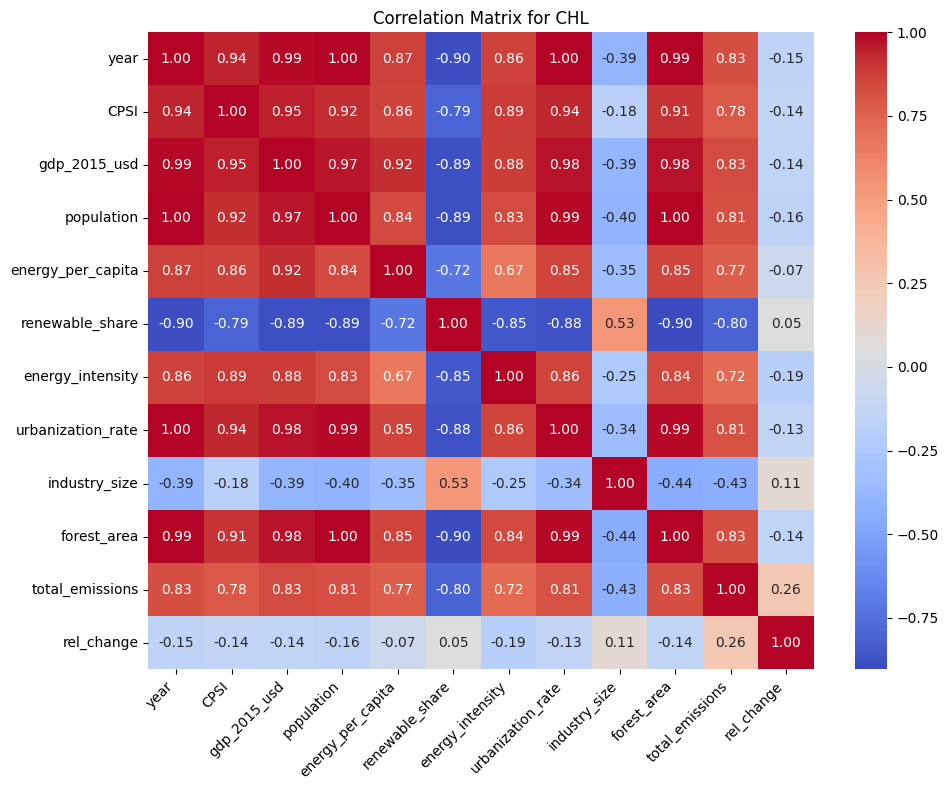

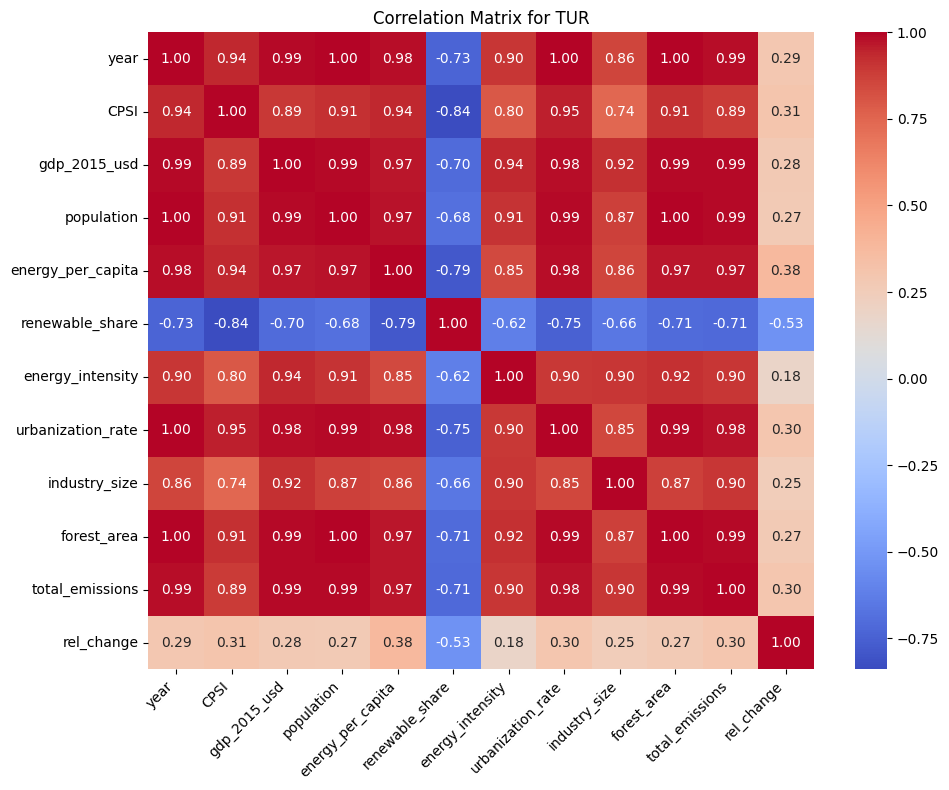

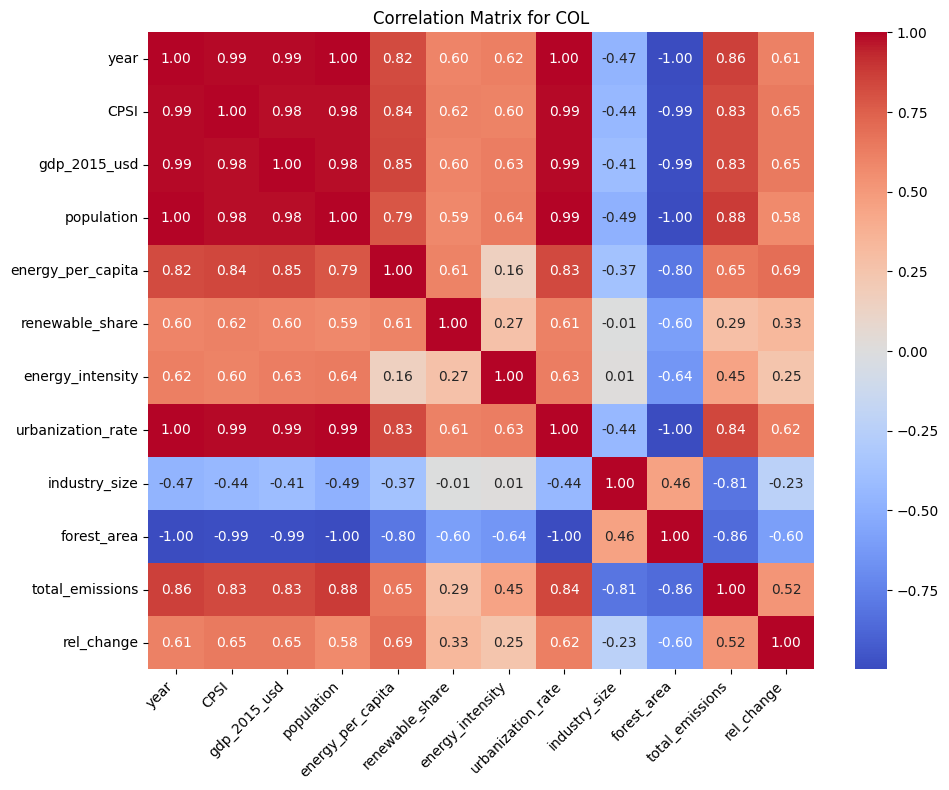

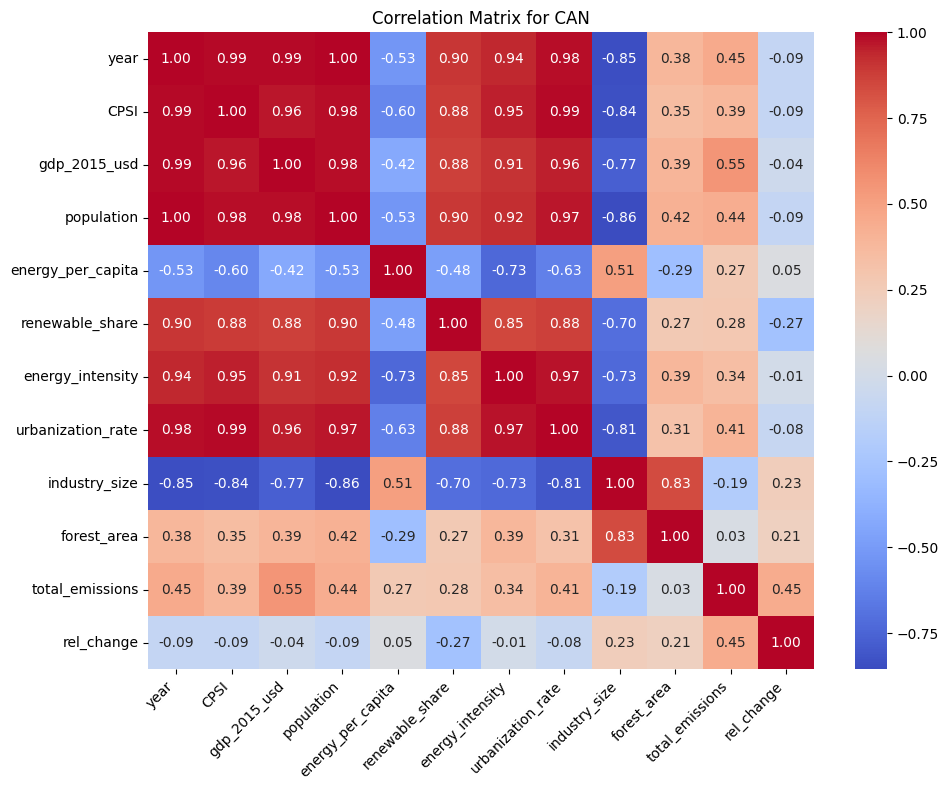

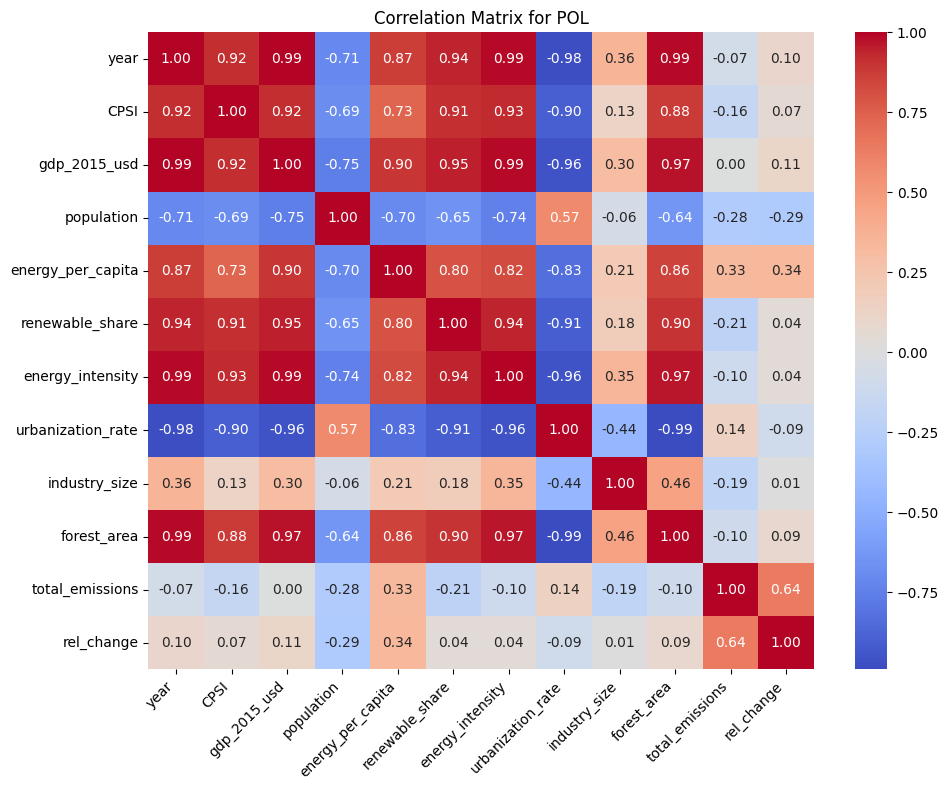

In [70]:
intersting_countries = ["USA", "DEU", "FRA", "MEX", "CHL", "TUR", "COL", "CAN", "POL"]

for iso_code in intersting_countries:
    eda.plot_correlation_matrix(oecd_policy_emissions_df, iso_code)

In [71]:
countries_corr_df = eda.calculate_corr_coef_for_each_country(oecd_policy_emissions_df, "CPSI", "total_emissions", oecd_countries_iso3)
countries_corr_df.sort_values(by="correlation", ascending=True).reset_index(drop=True)

,iso_alpha_3,correlation
0,DNK,-0.961211
1,GBR,-0.959544
2,DEU,-0.955458
3,GRC,-0.919700
4,FRA,-0.908937
5,USA,-0.905904
6,IRL,-0.904308
7,ITA,-0.883842
8,BEL,-0.877786
9,NLD,-0.862329


In [72]:
avg_cpsi_emissions_df = oecd_policy_emissions_df.groupby("iso_alpha_3")[["CPSI", "total_emissions", "rel_change"]].mean().reset_index()
avg_cpsi_emissions_df.rename(columns={"CPSI": "avg_cpsi", "total_emissions": "avg_total_emissions", "rel_change": "avg_rel_change"}, inplace=True)

# Calculate log of avg_total_emissions
avg_cpsi_emissions_df["log_avg_total_emissions"] = np.log(avg_cpsi_emissions_df["avg_total_emissions"])
avg_cpsi_emissions_df.head()

,iso_alpha_3,avg_cpsi,avg_total_emissions,avg_rel_change,log_avg_total_emissions
0,AUS,2.433358,589.814369,-0.005286,6.379808
1,AUT,1.914809,81.934979,0.006261,4.405926
2,BEL,1.951261,132.539855,-0.012501,4.886883
3,CAN,2.234306,728.584465,0.005878,6.591104
4,CHE,2.692150,49.741365,-0.012924,3.906837


In [73]:
avg_cpsi_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   iso_alpha_3              37 non-null     object 
 1   avg_cpsi                 37 non-null     float64
 2   avg_total_emissions      37 non-null     float64
 3   avg_rel_change           37 non-null     float64
 4   log_avg_total_emissions  37 non-null     float64
dtypes: float64(4), object(1)
memory usage: 1.6+ KB


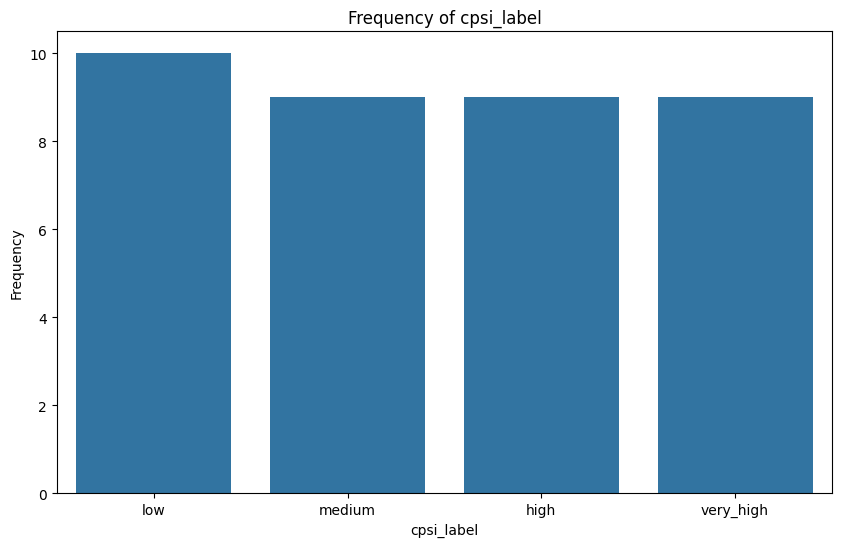

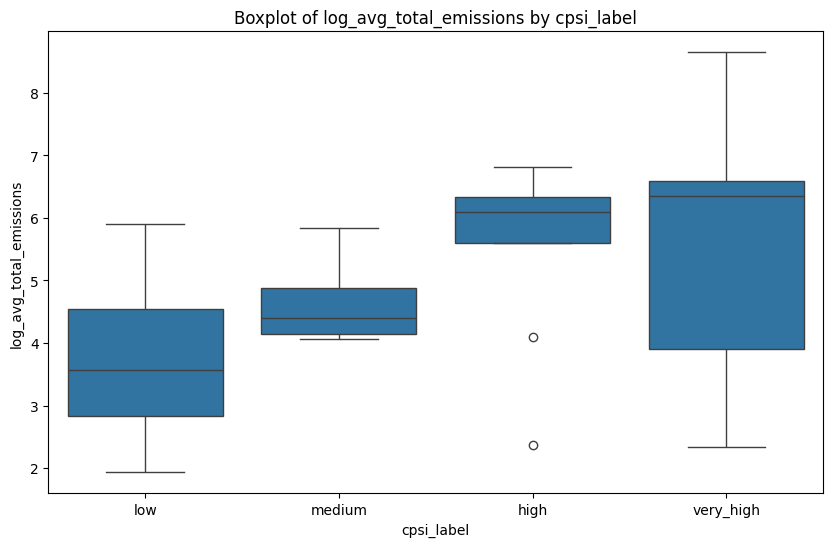

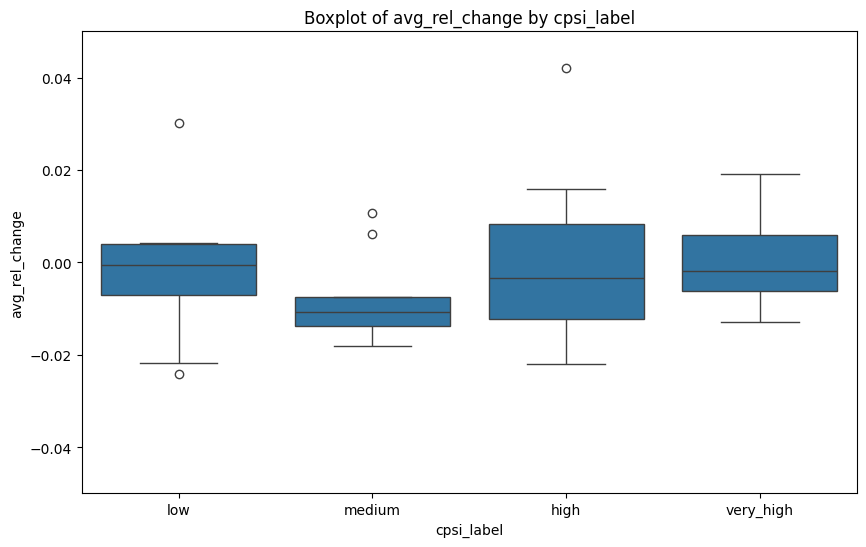

In [74]:
# label countries by their average CPSI score using quantiles
def label_countries_by_cpsi_score(df, cpsi_col, label_col):
    """
    Label countries by their average CPSI score using quantiles.
    """
    df[label_col] = pd.qcut(df[cpsi_col], q=4, labels=["low", "medium", "high", "very_high"])
    return df
avg_cpsi_emissions_df = label_countries_by_cpsi_score(avg_cpsi_emissions_df, "avg_cpsi", "cpsi_label")
# avg_cpsi_emissions_df.head()

# create frequency plot for each label
def plot_cpsi_label_frequency(df, label_col):
    """
    Plot frequency of each label.
    """
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=label_col)
    plt.title(f"Frequency of {label_col}")
    plt.xlabel(label_col)
    plt.ylabel("Frequency")
    plt.show()

plot_cpsi_label_frequency(avg_cpsi_emissions_df, "cpsi_label")

# Create a boxplot to visualize the distribution of CPSI scores for each label
def plot_cpsi_boxplot(df, emissions_col, label_col, ylim=None):
    """
    Plot boxplot of CPSI scores for each label.
    """
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x=label_col, y=emissions_col)
    plt.title(f"Boxplot of {emissions_col} by {label_col}")
    plt.xlabel(label_col)
    plt.ylabel(emissions_col)

    if ylim:
        plt.ylim(ylim)

    plt.show()
plot_cpsi_boxplot(avg_cpsi_emissions_df, "log_avg_total_emissions", "cpsi_label")
plot_cpsi_boxplot(avg_cpsi_emissions_df, "avg_rel_change", "cpsi_label", ylim=(-0.05, 0.05))

## Data preprocessing

In [75]:
oecd_policy_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 810 entries, 0 to 809
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   iso_alpha_3        810 non-null    object 
 1   year               810 non-null    int64  
 2   CPSI               810 non-null    float64
 3   gdp_2015_usd       810 non-null    float64
 4   population         810 non-null    float64
 5   energy_per_capita  810 non-null    float64
 6   renewable_share    773 non-null    float64
 7   energy_intensity   810 non-null    float64
 8   urbanization_rate  810 non-null    float64
 9   industry_size      806 non-null    float64
 10  forest_area        809 non-null    float64
 11  total_emissions    810 non-null    float64
 12  rel_change         810 non-null    float64
dtypes: float64(11), int64(1), object(1)
memory usage: 82.4+ KB


**Impute missing values**

In [76]:
# 1. Convert year to datetime
oecd_policy_emissions_df['year'] = pd.to_datetime(oecd_policy_emissions_df['year'], format='%Y')

# 2. Sort by country and year
oecd_policy_emissions_df = oecd_policy_emissions_df.sort_values(['iso_alpha_3', 'year'])

# 3. Forward-fill then backward-fill missing values per country
for col in ['renewable_share', 'industry_size', 'forest_area']:
    oecd_policy_emissions_df[col] = (
        oecd_policy_emissions_df
        .groupby('iso_alpha_3')[col]
        .transform(lambda x: x.ffill().bfill())
    )

# Convert year back to integer
oecd_policy_emissions_df['year'] = oecd_policy_emissions_df['year'].dt.year

In [77]:
oecd_policy_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 810 entries, 0 to 809
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   iso_alpha_3        810 non-null    object 
 1   year               810 non-null    int32  
 2   CPSI               810 non-null    float64
 3   gdp_2015_usd       810 non-null    float64
 4   population         810 non-null    float64
 5   energy_per_capita  810 non-null    float64
 6   renewable_share    810 non-null    float64
 7   energy_intensity   810 non-null    float64
 8   urbanization_rate  810 non-null    float64
 9   industry_size      810 non-null    float64
 10  forest_area        810 non-null    float64
 11  total_emissions    810 non-null    float64
 12  rel_change         810 non-null    float64
dtypes: float64(11), int32(1), object(1)
memory usage: 79.2+ KB


## ML

In [78]:
from utils.eda_utils import RegressionUtils
rutils = RegressionUtils()

In [97]:
# 2. Define features (including year), target, and countries
FEATURES = [
    "CPSI", "gdp_2015_usd", "population",
    "energy_per_capita", "renewable_share", "energy_intensity",
    "urbanization_rate", "industry_size", "forest_area"
]
TARGET = "total_emissions"

usa_df = oecd_policy_emissions_df[oecd_policy_emissions_df["iso_alpha_3"] == "USA"].copy()
usa_df.head()

,iso_alpha_3,year,CPSI,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area,total_emissions,rel_change
788,USA,2001,2.034283,1.384876e+13,284968955.0,7824.243939,4.7,7.031645,79.234,21.469006,33.186756,6237.645614,-0.012811
789,USA,2002,2.034711,1.408425e+13,287625193.0,7840.460959,4.8,7.070518,79.409,20.652475,33.243338,6102.809992,-0.021616
790,USA,2003,2.062921,1.447799e+13,290107933.0,7791.303915,5.3,7.251444,79.583,20.739462,33.299920,6142.901629,0.006569
791,USA,2004,2.207307,1.503507e+13,292805298.0,7878.537171,5.5,7.378481,79.757,20.950032,33.356502,6313.734481,0.027810
792,USA,2005,2.283475,1.555882e+13,295516599.0,7843.391057,5.8,7.599360,79.928,21.206273,33.413084,6263.301581,-0.007988


Features dropped due to collinearity: ['gdp_2015_usd', 'population', 'energy_per_capita', 'renewable_share', 'energy_intensity', 'urbanization_rate', 'industry_size', 'forest_area']
Reduced feature set: ['CPSI']

Model: LinearRegression
RMSE: 238.9809, R²: 0.5219

Coefficients:
CPSI   -414.102934
dtype: float64


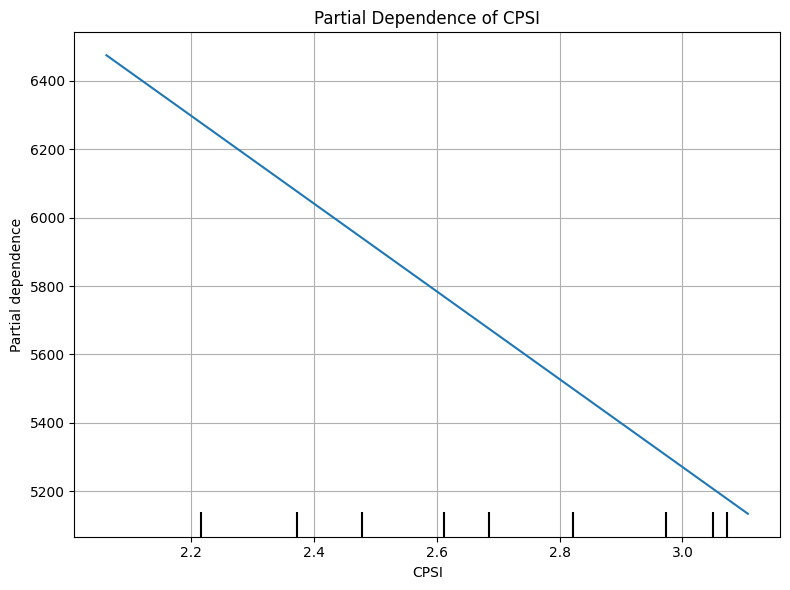

(Pipeline(steps=[('scaler', StandardScaler()),
                 ('regressor', LinearRegression())]),
 CPSI   -414.102934
 dtype: float64)

In [98]:
features_filtered = rutils.filter_high_collinear_features(usa_df, FEATURES)

# Linear regression
rutils.train_model(usa_df, features_filtered, TARGET, LinearRegression(), plot_pdp_feature="CPSI")


Model: Ridge
RMSE: 76.9775, R²: 0.9504

Coefficients:
energy_per_capita    228.799239
industry_size         92.616475
gdp_2015_usd          61.122010
forest_area           35.544875
CPSI                   4.045526
urbanization_rate     -7.629082
population           -13.913626
energy_intensity     -85.570146
renewable_share     -105.901257
dtype: float64


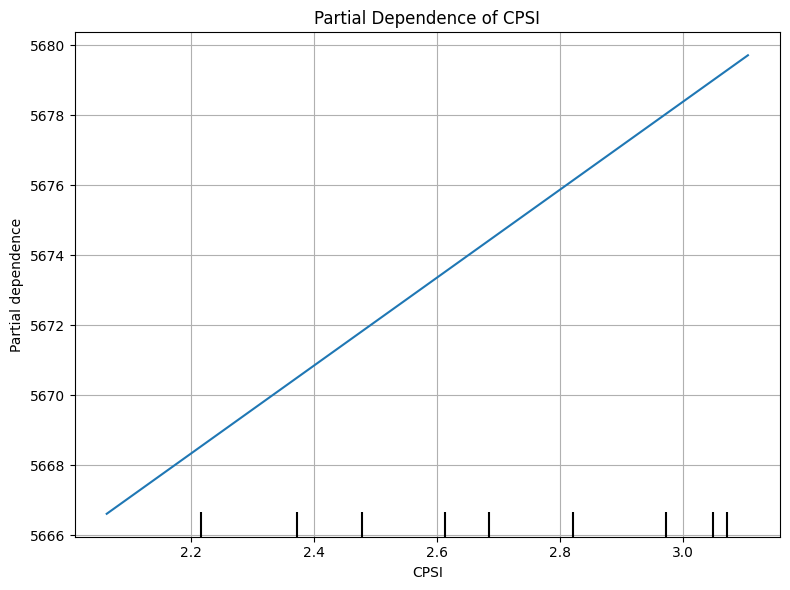

(Pipeline(steps=[('scaler', StandardScaler()), ('regressor', Ridge())]),
 CPSI                   4.045526
 gdp_2015_usd          61.122010
 population           -13.913626
 energy_per_capita    228.799239
 renewable_share     -105.901257
 energy_intensity     -85.570146
 urbanization_rate     -7.629082
 industry_size         92.616475
 forest_area           35.544875
 dtype: float64)

In [99]:
# Ridge regression
RegressionUtils.train_model(usa_df, FEATURES, TARGET, Ridge(alpha=1.0), plot_pdp_feature="CPSI")


SHAP Beeswarm (global feature importance):


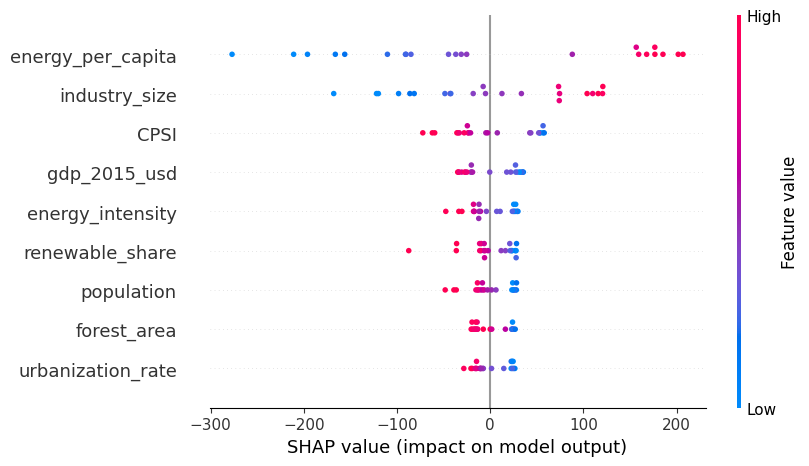


SHAP Scatter for feature: CPSI


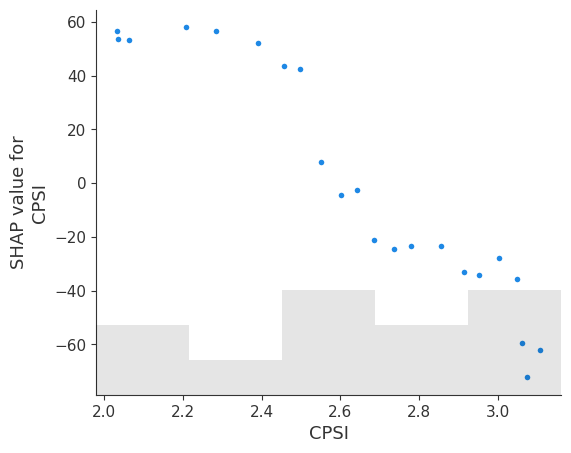

In [ ]:
RegressionUtils.analyze_feature_importance_with_shap(usa_df, FEATURES, target="total_emissions", plot_feature="CPSI")